# Imports

In [1]:
import pickle
from collections import Counter
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from osu_oracle_pytorch.oracle.utils_training import (get_data, get_additional_features, pad_sequences_pt,
                                                      train_and_evaluate, plot_training_history, load_pytorch_models)
from osu_oracle_pytorch.oracle.augment_faster import augment_dataset, extract_movement_features_from_X

# Model Testing

Go run test_model.py

# Setup

In [30]:
TOURNAMENT_MODS = {
    "nm1": "NM",
    "nm2": "NM",
    "nm3": "NM",
    "nm4": "NM",
    "nm5": "NM",
    "nm6": "NM",
    "hd1": "HD",
    "hd2": "HD",
    "hd3": "HD",
    "hr1": "HR",
    "hr2": "HR",
    "hr3": "HR",
    "dt1": "DT",
    "dt2_and_dt3": "DT",
    "dt4": "DT",
    "tiebreaker": "NM",
}

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'

X, y, beatmap_ids = get_data(db_path)
raw_additional_features, normalized_additional_features = get_additional_features(db_path, y, beatmap_ids)

Max Vector Length: 500.0
Max Time Diff: 86087.0
Tournament-labeled beatmaps: 3908
Max Vector Count: 6309
Original beatmaps: 3908


In [5]:
# Get the mod associated with each tournament label
mods_flattened = [
    TOURNAMENT_MODS[label]
    if TOURNAMENT_MODS[label]
    else "NM"
    for label in y
]

raw_additional_features_array = np.array([
    raw_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

normalized_additional_features_array = np.array([
    normalized_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

In [7]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    beatmap_ids_train,
    beatmap_ids_test,
) = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42,
)

print(f"Final train size: {len(X_train)}")
print(f"Final test size:  {len(X_test)}")

Final train size: 3126
Final test size:  782


In [8]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)

print(f"Using max sequence length: {max_length}")

X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)

X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print("Before metadata:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Using max sequence length: 4096
Before metadata:
X_train: torch.Size([3126, 4096, 8])
X_test:  torch.Size([782, 4096, 8])


In [9]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

Class 0: 702
Class 1: 694
Class 2: 733
Class 3: 612
Class 4: 385


In [10]:
print(dict(enumerate(label_encoder.classes_)))

{0: np.str_('nm1'), 1: np.str_('nm2'), 2: np.str_('nm3'), 3: np.str_('nm4'), 4: np.str_('nm5')}


In [11]:
# 1. Extract geometric summary vectors for each row in X_train and X_test
movement_features_train = np.array(
    [extract_movement_features_from_X(X_train[i]) for i in range(len(X_train))],
    dtype=np.float32,
)

movement_features_test = np.array(
    [extract_movement_features_from_X(X_test[i]) for i in range(len(X_test))],
    dtype=np.float32,
)

# 2. Extract SQLite metadata features corresponding to train/test IDs
sql_features_train = np.array(
    [
        normalized_additional_features[(b_id, "NM")]
        for b_id in beatmap_ids_train
    ],
    dtype=np.float32,
)

sql_features_test = np.array(
    [normalized_additional_features[(b_id, "NM")] for b_id in beatmap_ids_test],
    dtype=np.float32,
)

# 3. Concatenate (SQL metadata + Movement geometric summary)
X_additional_train = np.hstack(
    [sql_features_train, movement_features_train]
)
X_additional_test = np.hstack(
    [sql_features_test, movement_features_test]
)

print(f"Full meta tabular train shape: {X_additional_train.shape}")
print(f"Full meta tabular test shape:  {X_additional_test.shape}")

Full meta tabular train shape: (3126, 20)
Full meta tabular test shape:  (782, 20)


# CNN Model

--- Training Meta Fold 1/5 ---
Original samples: 2500 -> Augmented total: 10000
Epoch 1/30 - loss: 1.2048 - acc: 0.5833 - val_loss: 0.9769 - val_acc: 0.6869
Epoch 2/30 - loss: 1.0036 - acc: 0.6993 - val_loss: 0.9054 - val_acc: 0.7684
Epoch 3/30 - loss: 0.9647 - acc: 0.7235 - val_loss: 0.9293 - val_acc: 0.7508
Epoch 4/30 - loss: 0.9339 - acc: 0.7452 - val_loss: 0.8456 - val_acc: 0.7923
Epoch 5/30 - loss: 0.8821 - acc: 0.7760 - val_loss: 0.8153 - val_acc: 0.8067
Epoch 6/30 - loss: 0.8699 - acc: 0.7888 - val_loss: 0.7360 - val_acc: 0.8514
Epoch 7/30 - loss: 0.8408 - acc: 0.8003 - val_loss: 0.7516 - val_acc: 0.8403
Epoch 8/30 - loss: 0.8153 - acc: 0.8198 - val_loss: 0.7184 - val_acc: 0.8562
Epoch 9/30 - loss: 0.7903 - acc: 0.8329 - val_loss: 0.7074 - val_acc: 0.8626
Epoch 10/30 - loss: 0.7840 - acc: 0.8375 - val_loss: 0.7104 - val_acc: 0.8626
Epoch 11/30 - loss: 0.7560 - acc: 0.8513 - val_loss: 0.7764 - val_acc: 0.8275
Epoch 12/30 - loss: 0.7449 - acc: 0.8596 - val_loss: 0.7363 - val_acc: 

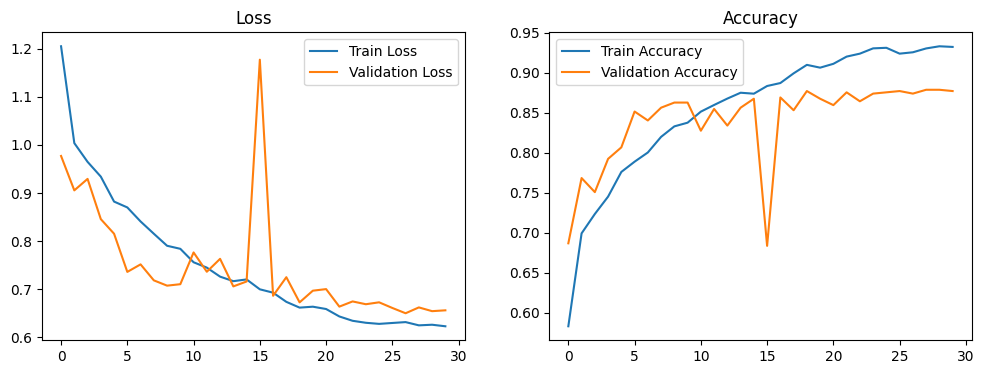

--- Training Meta Fold 2/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.2224 - acc: 0.5632 - val_loss: 0.9529 - val_acc: 0.7136
Epoch 2/30 - loss: 1.0400 - acc: 0.6776 - val_loss: 0.9327 - val_acc: 0.7008
Epoch 3/30 - loss: 0.9736 - acc: 0.7148 - val_loss: 0.8664 - val_acc: 0.7568
Epoch 4/30 - loss: 0.9442 - acc: 0.7357 - val_loss: 0.8641 - val_acc: 0.7744
Epoch 5/30 - loss: 0.9166 - acc: 0.7502 - val_loss: 0.8747 - val_acc: 0.7712
Epoch 6/30 - loss: 0.8840 - acc: 0.7700 - val_loss: 0.8207 - val_acc: 0.7840
Epoch 7/30 - loss: 0.8784 - acc: 0.7725 - val_loss: 0.7911 - val_acc: 0.8096
Epoch 8/30 - loss: 0.8418 - acc: 0.7955 - val_loss: 0.6934 - val_acc: 0.8608
Epoch 9/30 - loss: 0.8265 - acc: 0.8008 - val_loss: 0.6905 - val_acc: 0.8688
Epoch 10/30 - loss: 0.8178 - acc: 0.8053 - val_loss: 0.8983 - val_acc: 0.7632
Epoch 11/30 - loss: 0.7912 - acc: 0.8212 - val_loss: 0.8656 - val_acc: 0.7744
Epoch 12/30 - loss: 0.7935 - acc: 0.8242 - val_loss: 0.6586 - val_acc: 

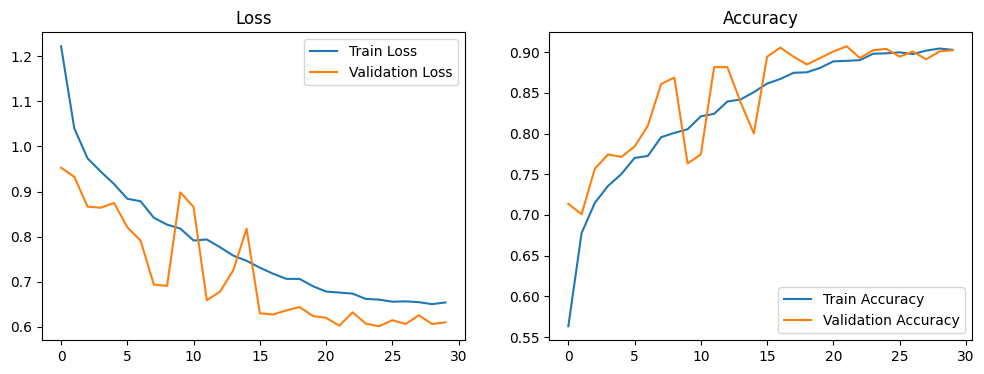

--- Training Meta Fold 3/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.2005 - acc: 0.5783 - val_loss: 0.9501 - val_acc: 0.7264
Epoch 2/30 - loss: 0.9852 - acc: 0.7124 - val_loss: 0.8632 - val_acc: 0.7856
Epoch 3/30 - loss: 0.9445 - acc: 0.7405 - val_loss: 0.8443 - val_acc: 0.7904
Epoch 4/30 - loss: 0.9083 - acc: 0.7652 - val_loss: 0.8162 - val_acc: 0.8000
Epoch 5/30 - loss: 0.8805 - acc: 0.7887 - val_loss: 0.8179 - val_acc: 0.7952
Epoch 6/30 - loss: 0.8318 - acc: 0.8108 - val_loss: 0.7897 - val_acc: 0.8128
Epoch 7/30 - loss: 0.8165 - acc: 0.8192 - val_loss: 0.7554 - val_acc: 0.8368
Epoch 8/30 - loss: 0.7870 - acc: 0.8358 - val_loss: 0.7108 - val_acc: 0.8512
Epoch 9/30 - loss: 0.7685 - acc: 0.8436 - val_loss: 0.7502 - val_acc: 0.8432
Epoch 10/30 - loss: 0.7544 - acc: 0.8587 - val_loss: 0.7316 - val_acc: 0.8528
Epoch 11/30 - loss: 0.7440 - acc: 0.8611 - val_loss: 0.7640 - val_acc: 0.8224
Epoch 12/30 - loss: 0.7309 - acc: 0.8688 - val_loss: 0.7556 - val_acc: 

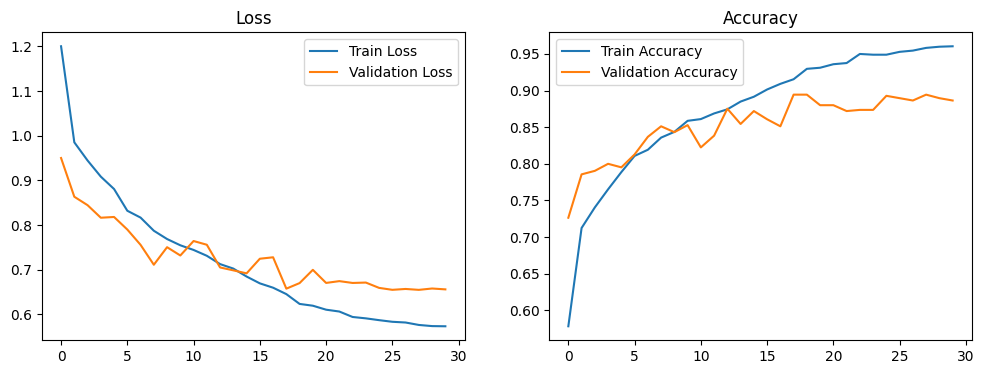

--- Training Meta Fold 4/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.2073 - acc: 0.5547 - val_loss: 0.9669 - val_acc: 0.6944
Epoch 2/30 - loss: 1.0053 - acc: 0.7030 - val_loss: 0.9160 - val_acc: 0.7520
Epoch 3/30 - loss: 0.9484 - acc: 0.7385 - val_loss: 0.8352 - val_acc: 0.7936
Epoch 4/30 - loss: 0.9020 - acc: 0.7693 - val_loss: 0.7896 - val_acc: 0.8192
Epoch 5/30 - loss: 0.8606 - acc: 0.7908 - val_loss: 0.7957 - val_acc: 0.8240
Epoch 6/30 - loss: 0.8379 - acc: 0.8044 - val_loss: 0.8173 - val_acc: 0.8192
Epoch 7/30 - loss: 0.8184 - acc: 0.8182 - val_loss: 0.7421 - val_acc: 0.8448
Epoch 8/30 - loss: 0.8054 - acc: 0.8270 - val_loss: 0.7675 - val_acc: 0.8336
Epoch 9/30 - loss: 0.7929 - acc: 0.8345 - val_loss: 0.7694 - val_acc: 0.8368
Epoch 10/30 - loss: 0.7748 - acc: 0.8467 - val_loss: 0.8385 - val_acc: 0.8048
Epoch 11/30 - loss: 0.7594 - acc: 0.8536 - val_loss: 0.7154 - val_acc: 0.8480
Epoch 12/30 - loss: 0.7474 - acc: 0.8555 - val_loss: 0.6910 - val_acc: 

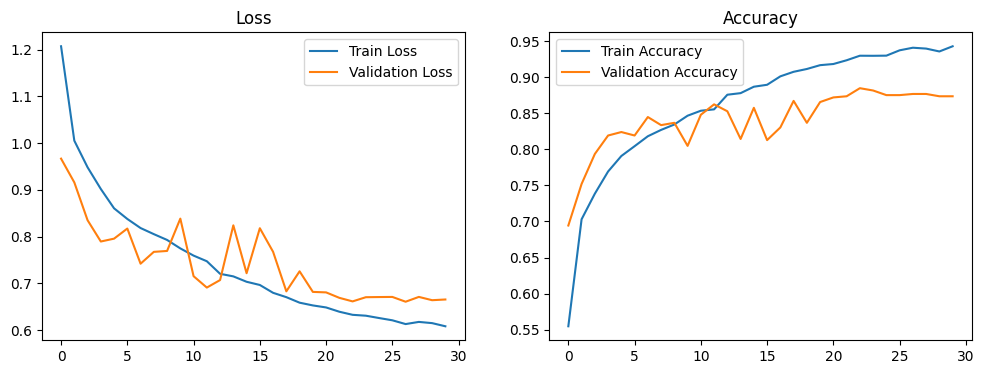

--- Training Meta Fold 5/5 ---
Original samples: 2501 -> Augmented total: 10004
Epoch 1/30 - loss: 1.1947 - acc: 0.6004 - val_loss: 1.0308 - val_acc: 0.6416
Epoch 2/30 - loss: 0.9821 - acc: 0.7122 - val_loss: 0.9460 - val_acc: 0.6960
Epoch 3/30 - loss: 0.9293 - acc: 0.7531 - val_loss: 0.8617 - val_acc: 0.7712
Epoch 4/30 - loss: 0.8922 - acc: 0.7735 - val_loss: 0.7959 - val_acc: 0.8176
Epoch 5/30 - loss: 0.8653 - acc: 0.7925 - val_loss: 0.8011 - val_acc: 0.8144
Epoch 6/30 - loss: 0.8375 - acc: 0.8133 - val_loss: 0.7641 - val_acc: 0.8336
Epoch 7/30 - loss: 0.8149 - acc: 0.8212 - val_loss: 0.8262 - val_acc: 0.7728
Epoch 8/30 - loss: 0.7852 - acc: 0.8448 - val_loss: 0.8556 - val_acc: 0.8048
Epoch 9/30 - loss: 0.7615 - acc: 0.8519 - val_loss: 0.8604 - val_acc: 0.7712
Epoch 10/30 - loss: 0.7465 - acc: 0.8597 - val_loss: 0.7479 - val_acc: 0.8400
Epoch 11/30 - loss: 0.7349 - acc: 0.8665 - val_loss: 0.8478 - val_acc: 0.7648
Epoch 12/30 - loss: 0.7199 - acc: 0.8739 - val_loss: 0.8732 - val_acc: 

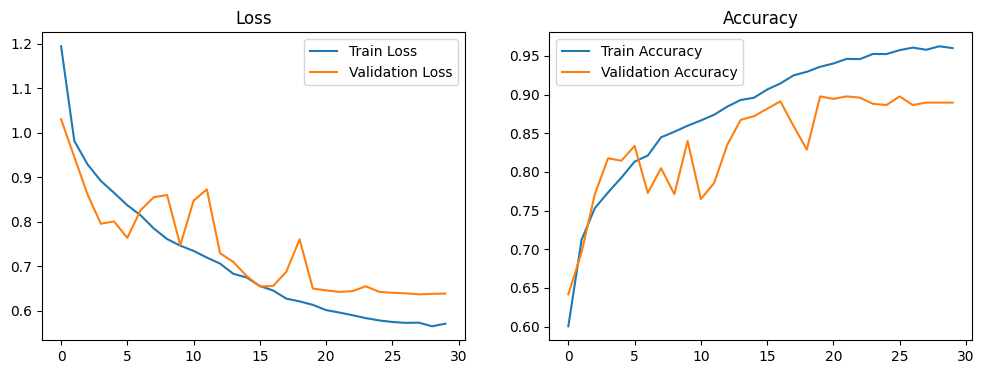

In [12]:
import numpy as np
import torch
from sklearn.model_selection import GroupKFold

meta_bagging_models = []
beatmap_ids_train = np.array(beatmap_ids_train)

# Initialize empty matrix for clean Out-Of-Fold CNN probability predictions
oof_cnn_predictions = np.zeros((len(X_train), num_classes), dtype=np.float32)

# Use GroupKFold so mapset difficulties stay grouped
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train_numerical, groups=beatmap_ids_train)):
    print(f"--- Training Meta Fold {fold + 1}/5 ---")

    # Split raw unaugmented fold data
    X_fold_train, y_fold_train = X_train[train_idx], y_train_numerical[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train_numerical[val_idx]
    beatmap_ids_fold_train = beatmap_ids_train[train_idx]

    # Augment ONLY the training fold
    X_fold_train_aug, y_fold_train_aug, _ = augment_dataset(
        X_fold_train,
        y_fold_train,
        beatmap_ids_fold_train,
        augmentation_types={"horizontal", "vertical", "horizontal_vertical"}
    )

    # Convert validation fold to PyTorch Tensor (permuted to (B, C, L))
    X_fold_val = torch.as_tensor(X_fold_val, dtype=torch.float32).permute(0, 2, 1)
    y_fold_val = torch.as_tensor(y_fold_val, dtype=torch.long)

    X_fold_train_aug = X_fold_train_aug.permute(0, 2, 1)

    # Train CNN model for this fold
    model, history = train_and_evaluate(
        X_fold_train_aug,
        y_fold_train_aug,
        X_fold_val,
        y_fold_val,
        input_channels=X_fold_train_aug.shape[1],
        num_classes=num_classes,
        max_length=max_length,
        learning_rate=0.001,
        dropout_rate=0.5,
        l2_reg=0.001,
        batch_size=128,
        epochs=30,
        patience=8
    )
    plot_training_history(history)
    meta_bagging_models.append(model)

    # Generate Out-of-Fold predictions for the unaugmented validation set ONLY
    model.eval()
    with torch.no_grad():
        val_inputs = X_fold_val.to(device)
        logits = model(val_inputs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Store clean OOF predictions in the array
    oof_cnn_predictions[val_idx] = probs

In [16]:
import os

os.makedirs('models/bagged_models', exist_ok=True)

for i, model in enumerate(meta_bagging_models):
    torch.save(model.state_dict(), f'models/bagged_models/bagged_cnn_model_{i}.pth')

In [17]:
# Generate Test probabilities by averaging predictions across all fold models
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
test_probs_list = []

for model in meta_bagging_models:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        test_probs_list.append(probs)

bagged_test_predictions = np.mean(test_probs_list, axis=0)
bagged_test_predictions_numerical = np.argmax(bagged_test_predictions, axis=1)

score = accuracy_score(y_test_numerical, bagged_test_predictions_numerical)
cm = confusion_matrix(y_test_numerical, bagged_test_predictions_numerical)
report = classification_report(
    y_test_numerical,
    bagged_test_predictions_numerical,
    zero_division=0
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       191
           1       0.89      0.92      0.90       172
           2       0.89      0.89      0.89       178
           3       0.88      0.85      0.86       149
           4       0.83      0.83      0.83        92

    accuracy                           0.90       782
   macro avg       0.89      0.89      0.89       782
weighted avg       0.90      0.90      0.90       782

Confusion Matrix:
 [[181   1   5   3   1]
 [  1 158   3   1   9]
 [  3   4 159  10   2]
 [  1   5  12 127   4]
 [  2  10   0   4  76]]
Accuracy: 0.8964194373401535


# XGBoost Meta Model

In [22]:
import os

print(os.getcwd())

/home/yoshi0428/PycharmProjects/osu-predict/osu_oracle_pytorch


In [25]:
from osu_oracle_pytorch.oracle.cnn_model import CNNModel

model_kwargs = {
    "input_channels": 8,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5,
}

meta_bagging_models = load_pytorch_models(
    model_folder="models/bagged_models",
    model_class=CNNModel,
    model_kwargs=model_kwargs,
    device=device,
)

print(f"Loaded {len(meta_bagging_models)} CNN models")

Loaded 5 CNN models


In [26]:
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

scaler = RobustScaler()
X_add_train_scaled = scaler.fit_transform(X_additional_train)
X_add_test_scaled = scaler.transform(X_additional_test)

X_meta_train = np.hstack([oof_cnn_predictions, X_add_train_scaled])
X_meta_test = np.hstack([bagged_test_predictions, X_add_test_scaled])

meta_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.015,
    max_depth=4,
    subsample=0.75,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
)

meta_model.fit(X_meta_train, y_train_numerical)

y_pred_meta = meta_model.predict(X_meta_test)
test_acc = accuracy_score(y_test_numerical, y_pred_meta)

print(f"--- XGBoost Meta-Model Performance ---")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test_numerical, y_pred_meta, target_names=["NM1", "NM2", "NM3", "NM4", "NM5"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test_numerical, y_pred_meta))

--- XGBoost Meta-Model Performance ---
Final Test Accuracy: 92.97%

Classification Report:
              precision    recall  f1-score   support

         NM1       0.98      0.95      0.97       191
         NM2       0.94      0.94      0.94       172
         NM3       0.92      0.91      0.92       178
         NM4       0.89      0.91      0.90       149
         NM5       0.89      0.95      0.92        92

    accuracy                           0.93       782
   macro avg       0.92      0.93      0.93       782
weighted avg       0.93      0.93      0.93       782

Confusion Matrix:
[[182   1   4   4   0]
 [  1 161   2   3   5]
 [  1   3 162   9   3]
 [  1   2   8 135   3]
 [  1   4   0   0  87]]


# Analysis

In [27]:
feature_names = [
    "AR",
    "OD",
    "Circle Size",
    "Star Rating",
    "BPM",
    "Max Combo",
    "Length (s)",
    "Object Count",
]

print("\nRaw Additional feature ranges:")
print("-" * 70)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    print(
        f"{name:15s} "
        f"min={np.min(values):8.2f}  "
        f"max={np.max(values):8.2f}  "
        f"mean={np.mean(values):8.2f}  "
        f"median={np.median(values):8.2f}"
    )

print("\nRaw Additional feature percentiles:")
print("-" * 90)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    p = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])

    print(
        f"{name:15s} "
        f"1%={p[0]:8.2f}  "
        f"5%={p[1]:8.2f}  "
        f"25%={p[2]:8.2f}  "
        f"50%={p[3]:8.2f}  "
        f"75%={p[4]:8.2f}  "
        f"95%={p[5]:8.2f}  "
        f"99%={p[6]:8.2f}"
    )


Raw Additional feature ranges:
----------------------------------------------------------------------
AR              min=    6.80  max=   10.00  mean=    9.50  median=    9.50
OD              min=    5.00  max=   10.00  mean=    8.87  median=    9.00
Circle Size     min=    2.00  max=    6.40  mean=    4.01  median=    4.00
Star Rating     min=    4.28  max=   10.12  mean=    6.79  median=    6.73
BPM             min=   50.00  max=  363.86  mean=  184.48  median=  185.00
Max Combo       min=  252.00  max=10215.00  mean= 1527.35  median= 1449.00
Length (s)      min=   18.29  max= 1645.53  mean=  192.91  median=  194.44
Object Count    min=  156.00  max= 6310.00  mean= 1086.77  median= 1023.00

Raw Additional feature percentiles:
------------------------------------------------------------------------------------------
AR              1%=    9.00  5%=    9.20  25%=    9.40  50%=    9.50  75%=    9.60  95%=    9.80  99%=   10.00
OD              1%=    7.50  5%=    8.00  25%=    8.50  50

In [28]:
bpm = raw_additional_features_array[:, 4]
for threshold in [300, 400, 500, 600, 800, 1000]:
    count = np.sum(bpm > threshold)

    print(
        f"bpm > {threshold:4d}: "
        f"{count:6d} "
        f"({count / len(bpm) * 100:.3f}%)"
    )

bpm >  300:      8 (0.205%)
bpm >  400:      0 (0.000%)
bpm >  500:      0 (0.000%)
bpm >  600:      0 (0.000%)
bpm >  800:      0 (0.000%)
bpm > 1000:      0 (0.000%)


In [29]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 3908
Min: 155
Median: 1022.0
Mean: 1085.7730296827021
75th: 1247.0
90th: 1578.3000000000002
95th: 1874.0
99th: 2547.0199999999977
Max: 6309


# Possibly Useful????

In [ ]:
# # Transform tournament labels into general skill labels
# # Keep original labels for anything that still needs tournament information
# y_tournament = np.array(y)
#
# beatmap_to_tournament_label = {
#     beatmap_id: label
#     for beatmap_id, label in zip(beatmap_ids, y_tournament)
# }
#
# (
#     X_train,
#     X_test,
#     y_train,
#     y_test,
#     beatmap_ids_train,
#     beatmap_ids_test,
#     features_train,
#     features_test,
#     y_tournament_train,
#     y_tournament_test,
# ) = train_test_split(
#     X,
#     y,
#     beatmap_ids,
#     normalized_additional_features_array,
#     y_tournament,
#     test_size=0.2,
#     random_state=42,
# )
#
# # AUGMENT TRAINING DATA ONLY
# X_train, y_train, beatmap_ids_train = augment_dataset(
#     X_train,
#     y_train,
#     beatmap_ids_train,
#
#     augmentation_types={
#         "horizontal",
#         "vertical",
#         "horizontal_vertical",
#     },
#
#     augmentation_ids=None,
# )
#
# # Duplicate additional features for augmented samples
# features_train = np.array([
#     normalized_additional_features[
#         (
#             beatmap_id,
#             TOURNAMENT_MODS[beatmap_to_tournament_label[beatmap_id]]
#         )
#     ]
#     for beatmap_id in beatmap_ids_train
# ])
#
# print(f"Final train size: {len(X_train)}")
# print(f"Final test size:  {len(X_test)}")
# print(f"Train features:   {features_train.shape}")
# print(f"Test features:    {features_test.shape}")
#
# # ---------------------------------------------------------
# # MERGE BEATMAP-LEVEL FEATURES
# # ---------------------------------------------------------
# # X shape:
# #   (batch, sequence_length, 8)
# #
# # features shape:
# #   (batch, 8)
# #
# # Repeat each beatmap's 8 metadata features across
# # the entire sequence:
# #
# #   (batch, 8)
# #       ->
# #   (batch, sequence_length, 16)
#
# train_metadata = (
#     torch.tensor(features_train, dtype=torch.float32)
#     .unsqueeze(1)
#     .expand(-1, X_train.shape[1], -1)
# )
#
# test_metadata = (
#     torch.tensor(features_test,dtype=torch.float32)
#     .unsqueeze(1)
#     .expand(-1, X_test.shape[1], -1)
# )
#
# # Concatenate:
# #   4 sequence features
# #   + 8 metadata features
# #   = 12 features per timestep
#
# X_train = torch.cat(
#     [X_train, train_metadata],
#     dim=2
# )
#
# X_test = torch.cat(
#     [X_test, test_metadata],
#     dim=2
# )
#
# print("After metadata:")
# print(f"X_train: {X_train.shape}")
# print(f"X_test:  {X_test.shape}")